In [1]:
!pip install tensorflow-datasets

     |████████████████████████████████| 4.2 MB 5.9 MB/s eta 0:00:01
     |████████████████████████████████| 95 kB 7.2 MB/s  eta 0:00:01
     |████████████████████████████████| 50 kB 7.4 MB/s  eta 0:00:01
  Using cached promise-2.3.tar.gz (19 kB)
  Created wheel for promise: filename=promise-2.3-py3-none-any.whl size=21503 sha256=c31fd61102686215f7f1df05b0c5305261af0c49b84c26baa8e687d68e986e2e
  Stored in directory: /Users/bisalgt/Library/Caches/pip/wheels/e1/e8/83/ddea66100678d139b14bc87692ece57c6a2a937956d2532608
Successfully built promise


In [2]:
!pip install tfds-nightly

     |████████████████████████████████| 4.3 MB 4.2 MB/s eta 0:00:01
     |████████████████████████████████| 87 kB 7.5 MB/s  eta 0:00:01


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

import tensorflow_datasets as tfds

In [4]:
tfds.list_builders() # list all the data sets

2022-05-26 09:22:06.153475: W tensorflow/core/platform/cloud/google_auth_provider.cc:184] All attempts to get a Google authentication bearer token failed, returning an empty token. Retrieving token from files failed with "NOT_FOUND: Could not locate the credentials file.". Retrieving token from GCE failed with "FAILED_PRECONDITION: Error executing an HTTP request: libcurl code 6 meaning 'Couldn't resolve host name', error details: Could not resolve host: metadata".


['abstract_reasoning',
 'accentdb',
 'aeslc',
 'aflw2k3d',
 'ag_news_subset',
 'ai2_arc',
 'ai2_arc_with_ir',
 'amazon_us_reviews',
 'anli',
 'answer_equivalence',
 'arc',
 'asqa',
 'asset',
 'assin2',
 'bair_robot_pushing_small',
 'bccd',
 'beans',
 'bee_dataset',
 'beir',
 'big_patent',
 'bigearthnet',
 'billsum',
 'binarized_mnist',
 'binary_alpha_digits',
 'ble_wind_field',
 'blimp',
 'booksum',
 'bool_q',
 'c4',
 'caltech101',
 'caltech_birds2010',
 'caltech_birds2011',
 'cardiotox',
 'cars196',
 'cassava',
 'cats_vs_dogs',
 'celeb_a',
 'celeb_a_hq',
 'cfq',
 'cherry_blossoms',
 'chexpert',
 'cifar10',
 'cifar100',
 'cifar10_1',
 'cifar10_corrupted',
 'citrus_leaves',
 'cityscapes',
 'civil_comments',
 'clevr',
 'clic',
 'clinc_oos',
 'cmaterdb',
 'cnn_dailymail',
 'coco',
 'coco_captions',
 'coil100',
 'colorectal_histology',
 'colorectal_histology_large',
 'common_voice',
 'coqa',
 'cos_e',
 'cosmos_qa',
 'covid19',
 'covid19sum',
 'crema_d',
 'criteo',
 'cs_restaurants',
 'cura

In [5]:
ds = tfds.load('mnist', split='train', shuffle_files=True)
assert isinstance(ds, tf.data.Dataset)
print(ds)

Dl Completed...:   0%|          | 0/4 [00:00<?, ? file/s]

Dataset mnist downloaded and prepared to ~/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.
<PrefetchDataset element_spec={'image': TensorSpec(shape=(28, 28, 1), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}>


2022-05-26 09:23:52.615839: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [7]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [8]:
ds = tfds.load('mnist', split='train', shuffle_files=True)
assert isinstance(ds, tf.data.Dataset)
print(ds)

<PrefetchDataset element_spec={'image': TensorSpec(shape=(28, 28, 1), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}>


In [9]:
ds, info = tfds.load('mnist', split='train', with_info=True)

tfds.as_dataframe(ds.take(4), info)

,image,label
0,,4
1,,1
2,,0
3,,7


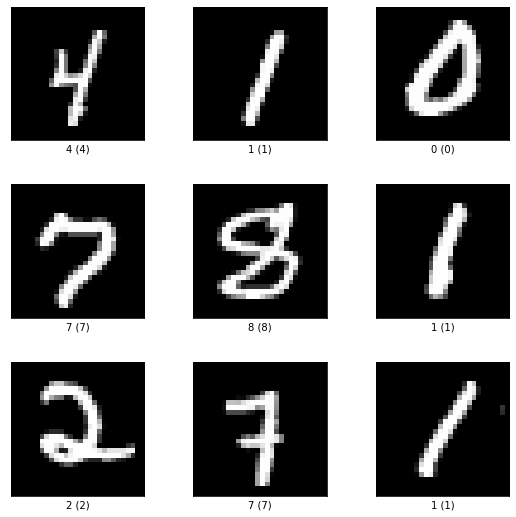

In [10]:
ds, info = tfds.load('mnist', split='train', with_info=True)

fig = tfds.show_examples(ds, info)

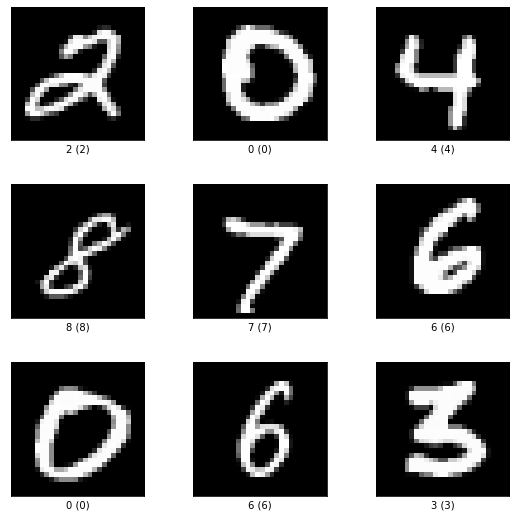

In [11]:
ds, info = tfds.load('mnist', split='test', with_info=True)

fig = tfds.show_examples(ds, info)

In [12]:
info

tfds.core.DatasetInfo(
    name='mnist',
    full_name='mnist/3.0.1',
    description="""
    The MNIST database of handwritten digits.
    """,
    homepage='http://yann.lecun.com/exdb/mnist/',
    data_path='~/tensorflow_datasets/mnist/3.0.1',
    file_format=tfrecord,
    download_size=11.06 MiB,
    dataset_size=21.00 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=tf.uint8),
        'label': ClassLabel(shape=(), dtype=tf.int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{lecun2010mnist,
      title={MNIST handwritten digit database},
      author={LeCun, Yann and Cortes, Corinna and Burges, CJ},
      journal={ATT Labs [Online]. Available: http://yann.lecun.com/exdb/mnist},
      volume={2},
      year={2010}
    }""",
)

### using keras mnist data set 

In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


inputs = keras.Input(shape=(784,), name="digits")
x = layers.Dense(64, activation="relu", name="dense_1")(inputs)
x = layers.Dense(64, activation="relu", name="dense_2")(x)
outputs = layers.Dense(10, activation="softmax", name="predictions")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

In [18]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Preprocess the data (these are NumPy arrays)
x_train = x_train.reshape(60000, 784).astype("float32") / 255
x_test = x_test.reshape(10000, 784).astype("float32") / 255

y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

# Reserve 10,000 samples for validation
x_val = x_train[-10000:]
y_val = y_train[-10000:]
x_train = x_train[:-10000]
y_train = y_train[:-10000]

11490434/11490434 [==============================] - 1s 0us/step


In [19]:
model.compile(
    optimizer=keras.optimizers.RMSprop(),  # Optimizer
    # Loss function to minimize
    loss=keras.losses.SparseCategoricalCrossentropy(),
    # List of metrics to monitor
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)

In [20]:
print("Fit model on training data")
history = model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=2,
    # We pass some validation for
    # monitoring validation loss and metrics
    # at the end of each epoch
    validation_data=(x_val, y_val),
)

Fit model on training data
Epoch 1/2
782/782 [==============================] - 2s 1ms/step - loss: 0.3410 - sparse_categorical_accuracy: 0.9025 - val_loss: 0.1685 - val_sparse_categorical_accuracy: 0.9529
Epoch 2/2
782/782 [==============================] - 1s 1ms/step - loss: 0.1582 - sparse_categorical_accuracy: 0.9534 - val_loss: 0.1361 - val_sparse_categorical_accuracy: 0.9620


In [21]:
history.history

{'loss': [0.3409903943538666, 0.1582176685333252],
 'sparse_categorical_accuracy': [0.9025400280952454, 0.9533600211143494],
 'val_loss': [0.16853316128253937, 0.13610130548477173],
 'val_sparse_categorical_accuracy': [0.9528999924659729, 0.9620000123977661]}

In [22]:
# Evaluate the model on the test data using `evaluate`
print("Evaluate on test data")
results = model.evaluate(x_test, y_test, batch_size=128)
print("test loss, test acc:", results)

# Generate predictions (probabilities -- the output of the last layer)
# on new data using `predict`
print("Generate predictions for 3 samples")
predictions = model.predict(x_test[:3])
print("predictions shape:", predictions.shape)

Evaluate on test data
79/79 [==============================] - 0s 1ms/step - loss: 0.1279 - sparse_categorical_accuracy: 0.9620
test loss, test acc: [0.12787987291812897, 0.9620000123977661]
Generate predictions for 3 samples
1/1 [==============================] - 0s 61ms/step
predictions shape: (3, 10)


In [23]:
print(predictions)

[[4.60235043e-07 4.89750178e-08 1.51754008e-04 5.69835720e-05
  3.79124430e-08 2.99728276e-06 5.55460495e-12 9.99751508e-01
  4.37849565e-07 3.57010576e-05]
 [1.14423547e-05 7.42743796e-05 9.99693274e-01 5.90512391e-05
  1.65012812e-11 7.92612627e-05 2.07555204e-05 7.74585784e-10
  6.19670827e-05 3.25211358e-10]
 [1.15827470e-06 9.92147982e-01 2.77603674e-03 1.40081102e-04
  1.01711834e-04 3.92594113e-04 4.44600410e-05 3.27050406e-03
  1.05343910e-03 7.22145123e-05]]


In [26]:
ds, info = tfds.load('mnist', split='test', with_info=True)

tfds.as_dataframe(ds.take(3), info)

,image,label
0,,2
1,,0
2,,4


In [29]:
y_test[:3]

array([7., 2., 1.], dtype=float32)

In [30]:
import scikitplot as skplt
import matplotlib.pyplot as plt

y_pred = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2])
y_test = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2])
skplt.metrics.plot_roc_curve(y_test, y_pred)
plt.show()

ModuleNotFoundError: No module named 'scikitplot'

In [31]:
!pip install scikitplot

ERROR: Could not find a version that satisfies the requirement scikitplot (from versions: none)
ERROR: No matching distribution found for scikitplot


In [33]:
from sklearn.metrics import roc_curve
#y_pred_keras = keras_model.predict(X_test).ravel()
y_pred = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2])
y_test = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2])

fpr_keras, tpr_keras, thresholds_keras = roc_curve(y_test, y_pred)
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_keras, tpr_keras, label='Keras (area = {:.3f})'.format(auc_keras))
plt.plot(fpr_rf, tpr_rf, label='RF (area = {:.3f})'.format(auc_rf))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()

ValueError: multiclass format is not supported